**Regression in Supernova II**

In [38]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

(35.0, 50.0)

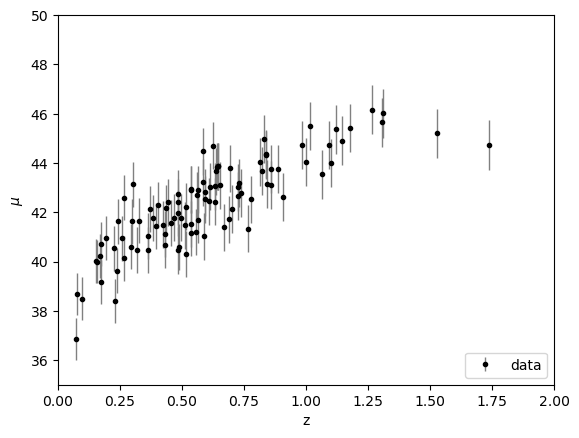

In [39]:
from astroML.datasets import generate_mu_z
z, mu, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

(35.0, 50.0)

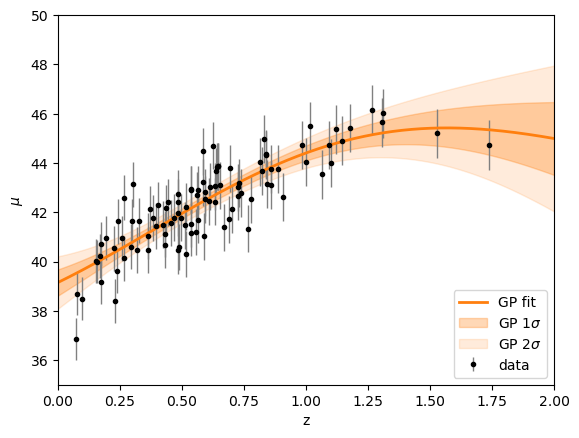

In [40]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels

kernel = kernels.ConstantKernel(1, constant_value_bounds=(1e-3, 1e3)) * kernels.RBF(length_scale=10, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, normalize_y=True)
gp.fit(z[:, np.newaxis], mu)
z_fit = np.linspace(0, 2, 1000)[:, np.newaxis]
mu_fit, dmu_fit = gp.predict(z_fit, return_std=True)

plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_fit, mu_fit, color='C1', lw=2, label='GP fit')
plt.fill_between(z_fit.ravel(), mu_fit - dmu_fit, mu_fit + dmu_fit, color='C1', alpha=0.3, label='GP $1\sigma$')
plt.fill_between(z_fit.ravel(), mu_fit - 2*dmu_fit, mu_fit + 2*dmu_fit, color='C1', alpha=0.15, label='GP $2\sigma$')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0, 2)
plt.ylim(35, 50)

***Lambda CDM Model***

We want to study this parametrically (i.e. fitting a given physical model) such that:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z)^3+\Omega_\Lambda}} \right) $$

In [125]:
# Define the model
def LambdaCDM(z, H0, omegaM):
    c = 299792.458
    omegaL = 1 - omegaM

    def integrand(x):
        return 1.0 / np.sqrt(omegaM * (1 + x)**3 + omegaL)

    z_arr = np.atleast_1d(z)
    integral = np.array([scipy.integrate.quad(integrand, 0, zi)[0] for zi in z_arr])
    d_l_mpc = (100000 * c / H0) * (1 + z_arr) * integral
    mu = 5 * np.log10(d_l_mpc)

    return mu.item() if np.isscalar(z) else mu

# Define the logLikelihood
def logLikelihood(theta, z, mu, error):
    H0, omegaM = theta
    model = LambdaCDM(z, H0, omegaM)
    logL = -0.5 * np.sum(((mu - model) / error) ** 2)
    return logL

# Define the logPrior
def logPrior(theta):
    H0, omegaM = theta
    if 0 < H0 < 100 and 0 < omegaM < 1:
        return 0.0  
    return -np.inf  

# Define the prior transformation
def priorTransform(u):
    H0 = 100 * u[0]  # Map u[0] from [0, 1] to [0, 100]
    omegaM = u[1]  # Map u[1] from [0, 1] to [0, 1]
    return H0, omegaM

# Define logPosterior
def logPosterior(theta, z, mu, error):
    lp = logPrior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta, z, mu, error)

In [126]:
LambdaCDM(0.2, 70, 0.3)

39.95628079616643

In [127]:
import emcee

ndim = 2
nwalkers = 100
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(z, mu, dmu))
initial = np.array([70, 0.3]) + 1e-4 * np.random.randn(nwalkers, ndim)

sampler.run_mcmc(initial, 5000, progress=True)

100%|██████████| 5000/5000 [18:44<00:00,  4.45it/s]  


State([[6.53078883e+01 5.39024140e-01]
 [5.89805322e+01 7.02716440e-01]
 [6.05407364e+01 7.42172057e-01]
 [5.91919055e+01 8.87829114e-01]
 [6.25614967e+01 4.78718619e-01]
 [7.74584383e+01 1.83341190e-01]
 [7.75050469e+01 7.56562660e-02]
 [6.69616067e+01 4.90697433e-01]
 [7.17685602e+01 2.67665196e-01]
 [7.95558006e+01 2.86614307e-02]
 [6.05785298e+01 7.79759206e-01]
 [7.24554000e+01 1.98177715e-01]
 [6.52674261e+01 3.17343967e-01]
 [6.30705880e+01 4.33999031e-01]
 [6.04466724e+01 7.51135418e-01]
 [6.84801957e+01 2.01286786e-01]
 [6.95556470e+01 5.63864599e-01]
 [6.16273468e+01 5.31080762e-01]
 [6.84918262e+01 4.67474897e-01]
 [7.12002212e+01 1.11377379e-01]
 [6.01263663e+01 8.04855982e-01]
 [7.05743805e+01 4.64281134e-01]
 [6.20279342e+01 7.53157936e-01]
 [7.94807817e+01 7.54193060e-02]
 [6.47123260e+01 5.46500867e-01]
 [6.54634343e+01 4.62270355e-01]
 [7.05609161e+01 5.38632569e-01]
 [7.86240915e+01 4.83755645e-02]
 [7.73588481e+01 3.50729095e-02]
 [7.27737780e+01 9.97132227e-02]
 [7.

In [128]:
samples = sampler.get_chain(discard=1000, thin=max(1, int(np.max(sampler.get_autocorr_time())) * 10), flat=True)

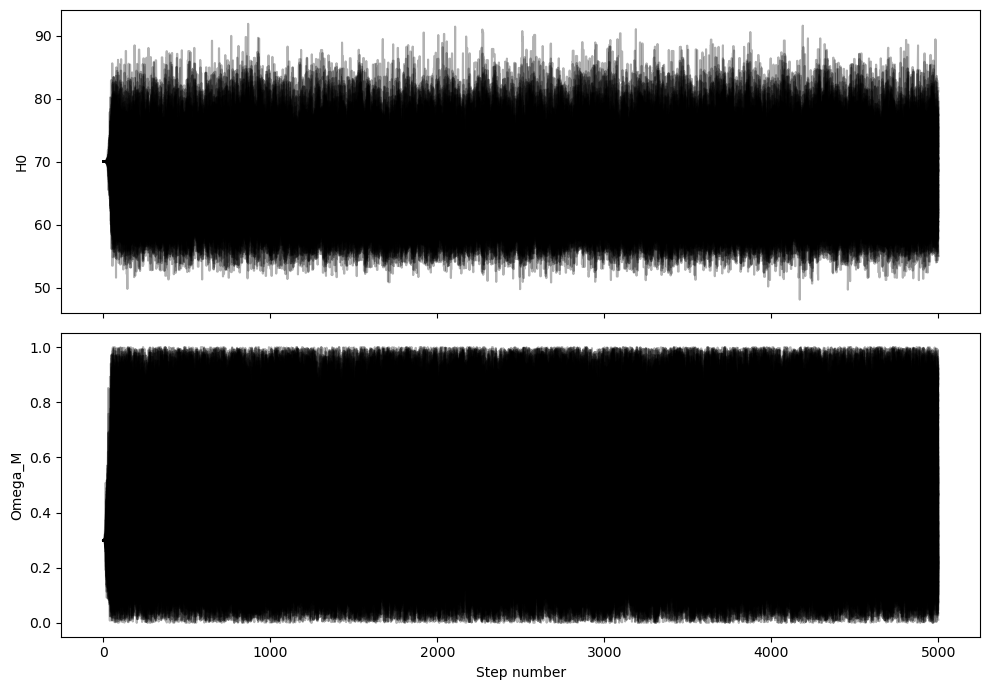

In [129]:
labels = ["H0", "Omega_M"]

fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(sampler.get_chain()[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()

plt.show()

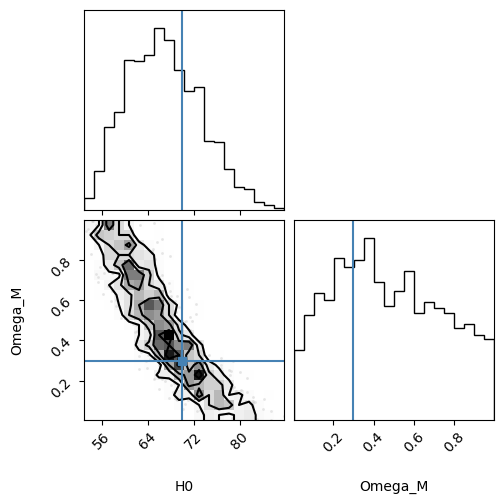

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_51739/948458971.py:12: RuntimeWarning: divide by zero encountered in log10
  mu = 5 * np.log10(d_l_mpc)


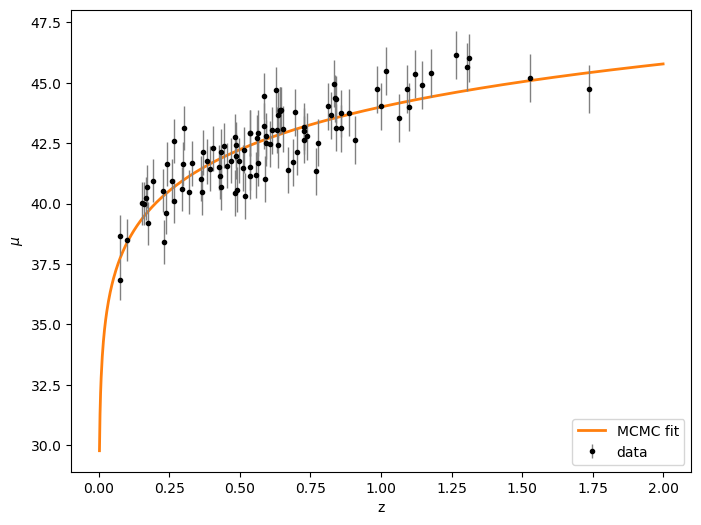

In [133]:
import corner

corner.corner(samples, labels=labels, truths=[70, 0.3])
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(z_fit.ravel(), LambdaCDM(z_fit.ravel(), *samples.mean(axis=0)), color='C1', lw=2, label='MCMC fit')
plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.show()

In [121]:
import dynesty

sampler = dynesty.NestedSampler(logLikelihood, priorTransform, ndim, nlive=1000, logl_args=(z, mu, dmu))
sampler.run_nested()
samples = sampler.results['samples']

3199it [00:59, 53.44it/s, +1000 | bound: 0 | nc: 1 | ncall: 24963 | eff(%): 17.523 | loglstar:   -inf < -46.387 <    inf | logz: -49.312 +/-  0.031 | dlogz:  0.001 >  1.009]


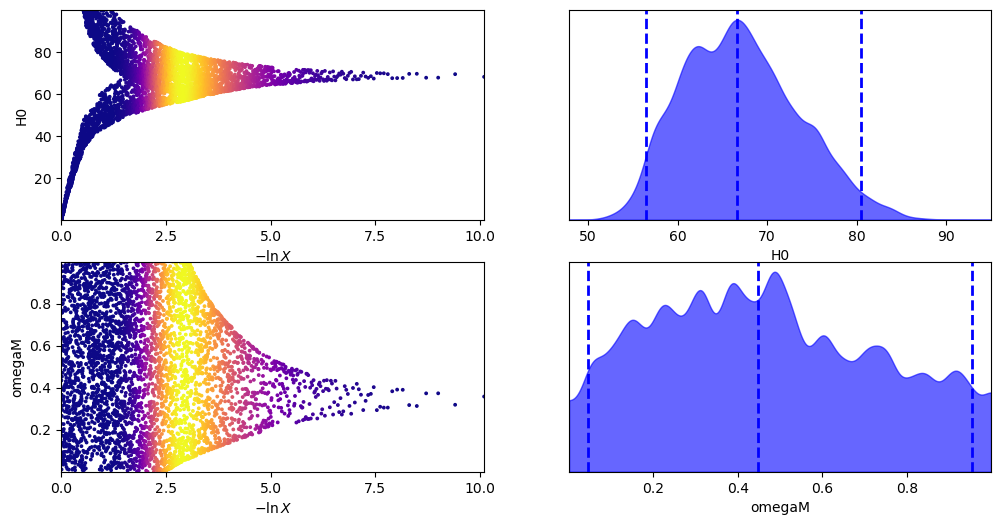

In [122]:
from dynesty import plotting as dyplot

labels = ["H0", "omegaM"]
fig, axes = dyplot.traceplot(sampler.results, labels=labels)
plt.show()

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_51739/948458971.py:12: RuntimeWarning: divide by zero encountered in log10
  mu = 5 * np.log10(d_l_mpc)


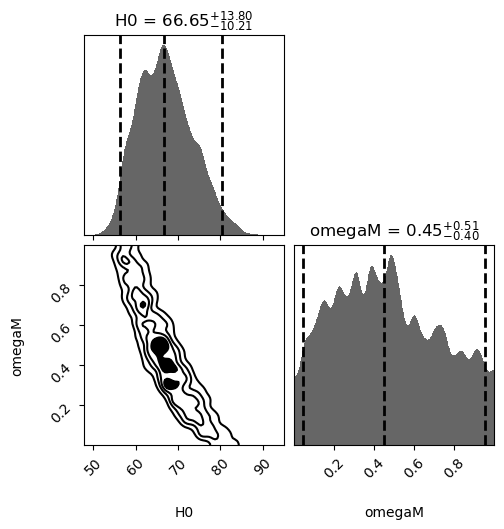

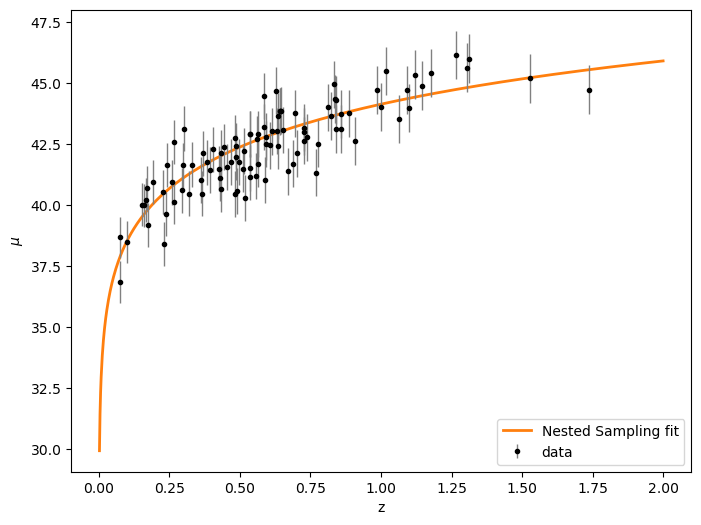

In [124]:
dyplot.cornerplot(sampler.results, labels=labels, show_titles=True)

plt.figure(figsize=(8, 6))
plt.plot(z_fit.ravel(), LambdaCDM(z_fit.ravel(), *sampler.results['samples'].mean(axis=0)), color='C1', lw=2, label='Nested Sampling fit')
plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.show()

***Cloning data set***

In [ ]:
from sklearn.kernel_density import KernelDensity as KDE

